In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

MAIN = Path("/Users/hintont/Dev/projects/ridgecrest")
sys.path.insert(0, str(MAIN / "scripts"))
sys.path.insert(0, "/Users/hintont/Dev/codes/src")

FAULT_DIR = MAIN / "data" / "fault"
FIGURES = Path("figures")   # pre-generated images copied next to this notebook

## 1. Fault meshing

In [2]:
%matplotlib widget
import pickle

# mesh_fault.py now builds each strand with codes.helpers.remesh_fault and
# saves it as a plain FaultTriangles pickle (no more RemeshedFault/.npz)
rfs = []
for label, fname in [("mainshock", "mainshock_fault.pickle"),
                     ("foreshock", "foreshock_fault.pickle")]:
    rf = pickle.load(open(FAULT_DIR / fname, "rb"))
    print(f"{label}: {rf.n_patches} triangles, {len(rf.vertices)} vertices")
    for L in np.unique(rf.layers):
        z = rf.vertices[rf.triangles[rf.layers == L]][:, :, 2]
        print(f"   layer {L}: {-z.max():.0f}-{-z.min():.0f} m depth")
    rfs.append(rf)

mainshock: 284 triangles, 172 vertices
   layer 0: 1-1500 m depth
   layer 1: 1500-3000 m depth
   layer 2: 3000-5500 m depth
   layer 3: 5500-8500 m depth
   layer 4: 8500-11500 m depth
   layer 5: 11500-15000 m depth
foreshock: 140 triangles, 88 vertices
   layer 0: 1-1500 m depth
   layer 1: 1500-3000 m depth
   layer 2: 3000-5500 m depth
   layer 3: 5500-8500 m depth
   layer 4: 8500-11500 m depth
   layer 5: 11500-15000 m depth


**Interactive 3D mesh** — drag to rotate (both strands, coloured by depth layer; note the shared contour vertices and the coarsening with depth):

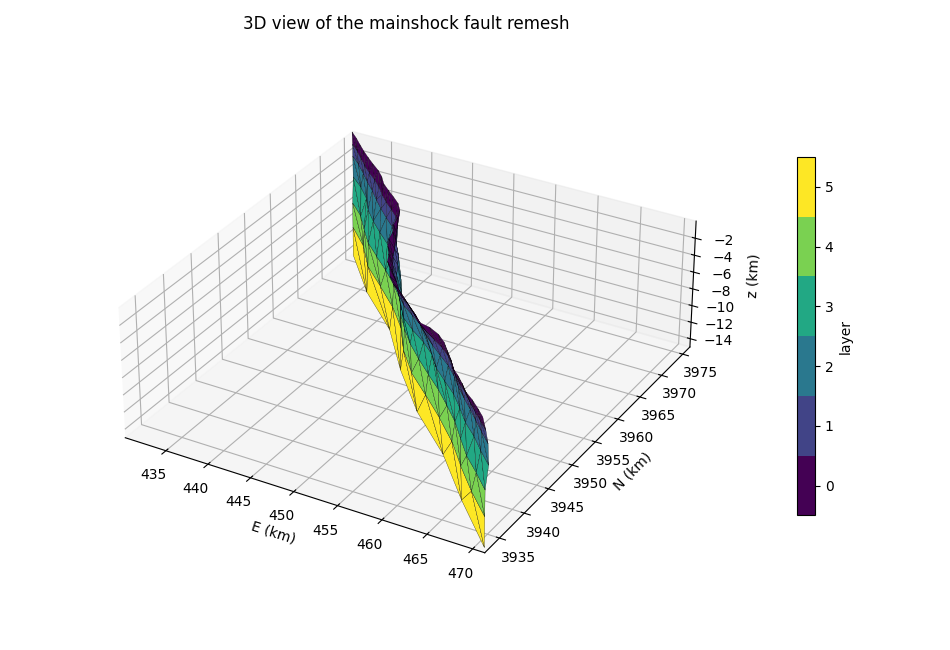

In [3]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

n_layers = max(int(rf.layers.max()) for rf in rfs) + 1
cmap = plt.get_cmap("viridis", n_layers)
norm = plt.Normalize(-0.5, n_layers - 0.5)

fig = plt.figure(figsize=(9.5, 6.5))
ax = fig.add_subplot(111, projection="3d")
for rf in [rfs[0]]:
    tri_xyz = (rf.vertices * 1e-3)[rf.triangles]          # km
    ax.add_collection3d(Poly3DCollection(tri_xyz, facecolors=cmap(norm(rf.layers)),
                                         edgecolors="k", linewidths=0.2))
allpts = np.vstack([rf.vertices for rf in rfs]) * 1e-3
ax.set_xlim(allpts[:, 0].min(), allpts[:, 0].max())
ax.set_ylim(allpts[:, 1].min(), allpts[:, 1].max())
ax.set_zlim(allpts[:, 2].min(), allpts[:, 2].max())
ax.set_box_aspect(np.ptp(allpts, axis=0))
ax.set_xlabel("E (km)"); ax.set_ylabel("N (km)"); ax.set_zlabel("z (km)")
ax.set_title("3D view of the mainshock fault remesh")
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.1, ticks=range(n_layers), label="layer")
fig.tight_layout()

FaultTriangles(name='Ridgecrest Faults', 424 triangles, 260 vertices)


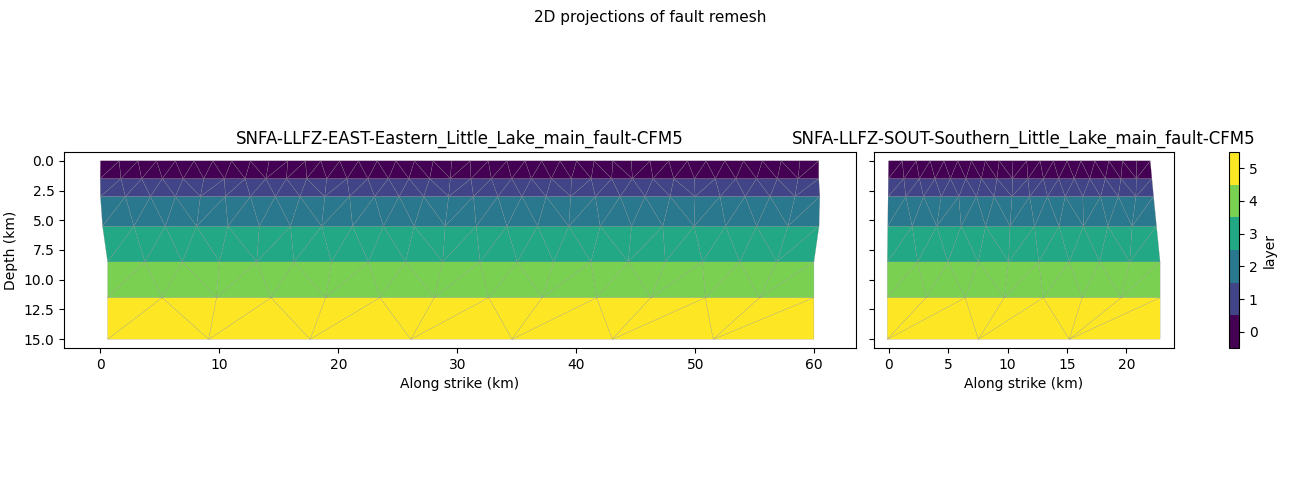

In [4]:
from codes import FaultTriangles

fault = FaultTriangles.merge(rfs)
fault.name = "Ridgecrest Faults"
print(fault)

fig, axes = fault.plot_slip_2d(slip=fault.layers, cmap=cmap,
                               vmin=-0.5, vmax=n_layers - 0.5,
                               colorbar_label="layer")
fig.suptitle("2D projections of fault remesh", fontsize=11);

## 2. Data preparation
![covariance](figures/prep/covariance_fit.png)

## 3. Quick least-squares inversions

N.b. Optical data are never in the fit, just visualised for comparison.

### 3.1 Ascending InSAR only

![slip](figures/lsq_asc/quick_lsq_slip_2d.png)
![fit A064](figures/lsq_asc/quick_lsq_fit_A064.png)
![optical](figures/lsq_asc/quick_lsq_optical_residuals.png)

### 3.2 Descending InSAR only

![slip](figures/lsq_desc/quick_lsq_slip_2d.png)
![fit D071](figures/lsq_desc/quick_lsq_fit_D071.png)
![optical](figures/lsq_desc/quick_lsq_optical_residuals.png)

### 3.3 Ascending + GNSS

![slip](figures/lsq_asc_gnss/quick_lsq_slip_2d.png)
![fit A064](figures/lsq_asc_gnss/quick_lsq_fit_A064.png)
![optical](figures/lsq_asc_gnss/quick_lsq_optical_residuals.png)

### 3.4 Descending + GNSS

![slip](figures/lsq_desc_gnss/quick_lsq_slip_2d.png)
![fit D071](figures/lsq_desc_gnss/quick_lsq_fit_D071.png)
![optical](figures/lsq_desc_gnss/quick_lsq_optical_residuals.png)

### 3.5 Ascending + descending + GNSS

![slip](figures/lsq_asc_desc_gnss/quick_lsq_slip_2d.png)
![fit A064](figures/lsq_asc_desc_gnss/quick_lsq_fit_A064.png)
![fit D071](figures/lsq_asc_desc_gnss/quick_lsq_fit_D071.png)
![optical](figures/lsq_asc_desc_gnss/quick_lsq_optical_residuals.png)

### Summary of Least squares inversions

**Post-fit residual RMS**

| Case | A064 LOS (cm) | D071 LOS (cm) | GNSS (mm) | Optical EW (m) | Optical NS (m) |
|---|---|---|---|---|---|
| Ascending InSAR only (A064) | 10.4 | -- | 57.2* | 0.51 | 0.63 |
| Descending InSAR only (D071) | -- | 7.6 | 17.3* | 0.40 | 0.46 |
| Ascending + GNSS | 11.2 | -- | 15.4 | 0.43 | 0.52 |
| Descending + GNSS | -- | 6.9 | 7.7 | 0.37 | 0.43 |
| Ascending + descending + GNSS | 12.3 | 7.5 | 9.8 | 0.36 | 0.40 |

## 4. AlTar Bayesian inversion

### Data fits

![fit D071](figures/altar/fit_D071.png)
![fit gnss](figures/altar/fit_gnss.png)

Near-field check — optical image correlation (not inverted):
![fit optical](figures/altar/fit_optical_check.png)

### Slip distribution

![bivariate](figures/altar/slip_bivariate_sigma.png)

Strike-slip most-likely model:
![ss 2d](figures/altar/slip2d_strikeslip.png)

Dip-slip most-likely model:
![dip 2d](figures/altar/slip2d_dipslip.png)

Posterior distributions for a random selection of patches:
![random posteriors](figures/altar/patch_pdfs_random_3.png)

## 5.Deep-slip only surface displacement


![deep slip](figures/altar/deep_slip_surface_displacement.png)

## 6. Profile picking

Interactive picker (`pick_profiles.py`): 123 quick swath profiles cast perpendicular to both fault strands, kept/rejected (and trimmed) by eye against the optical EW map. 34 kept for accurate re-evaluation — numbered below in pick order, which is the profile index used in every later section.

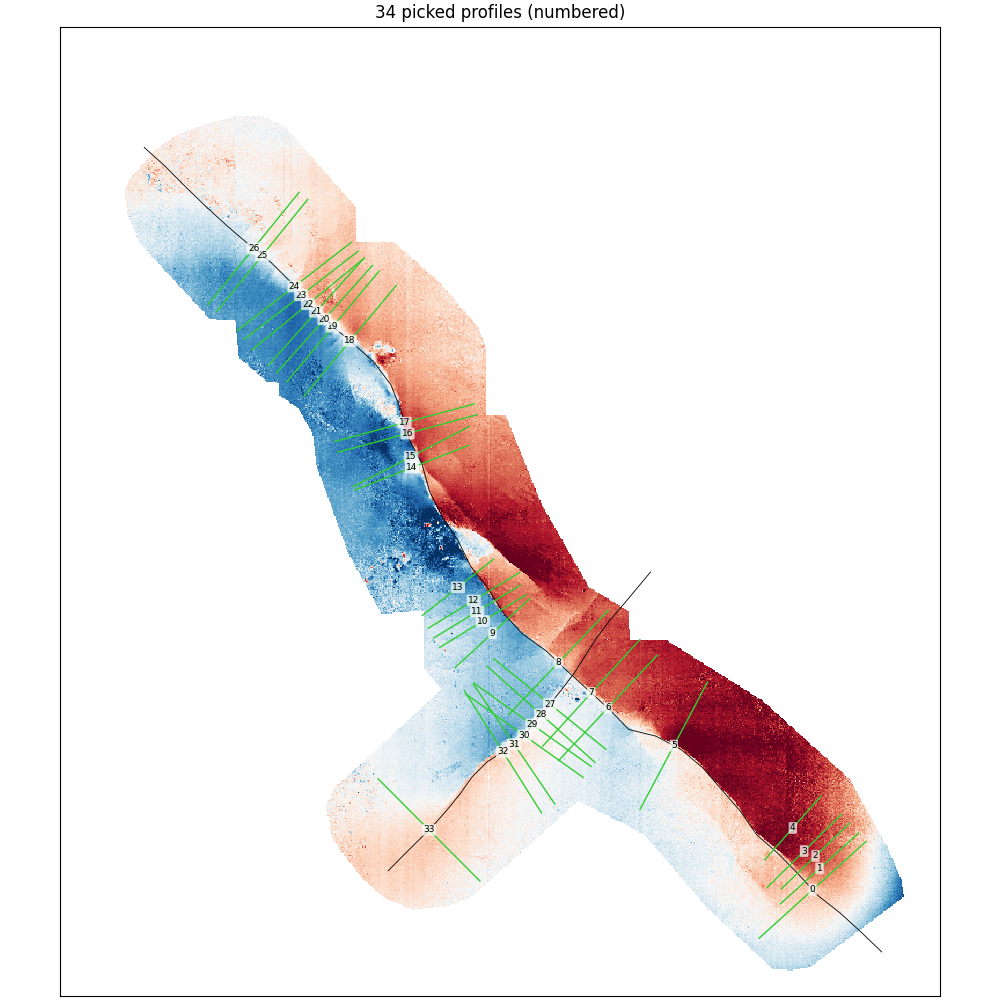

In [11]:
import pickle

picked_fault = pickle.load(open(FAULT_DIR / "ridgecrest_faults.pickle", "rb"))
picked = pickle.load(open(MAIN / "results" / "working" / "tmp" / "picked_profiles.pickle", "rb"))
z = np.load(MAIN / "results" / "working" / "tmp" / "optical_minimap.npz")
bg, extent = z["bg"], z["extent"]

fig, ax = plt.subplots(figsize=(10, 10), layout="constrained")
vmax = np.nanpercentile(np.abs(bg), 98)
ax.imshow(bg, extent=extent, origin="upper", cmap="RdBu_r", vmin=-vmax, vmax=vmax,
         interpolation="nearest")
for g in picked_fault.trace.geometry:
    xy = np.asarray(g.coords)
    ax.plot(xy[:, 0], xy[:, 1], "k-", lw=0.6)
for i, p in enumerate(picked):
    c = np.asarray(p.linestring.coords)
    u = (c[-1] - c[0]) / np.hypot(*(c[-1] - c[0]))
    a = c[0] + (p.xs.min() + p.fault_x) * u
    b = c[0] + (p.xs.max() + p.fault_x) * u
    ax.plot([a[0], b[0]], [a[1], b[1]], "-", color="limegreen", lw=1.)
    ax.annotate(str(i), (a + b) / 2, fontsize=6.5, ha="center", va="center",
               bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7))
ax.set_aspect("equal")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"{len(picked)} picked profiles (numbered)");

Browse any of the candidate profiles by index:

interactive(children=(BoundedIntText(value=0, description='index:', max=122), Output()), _dom_classes=('widget…

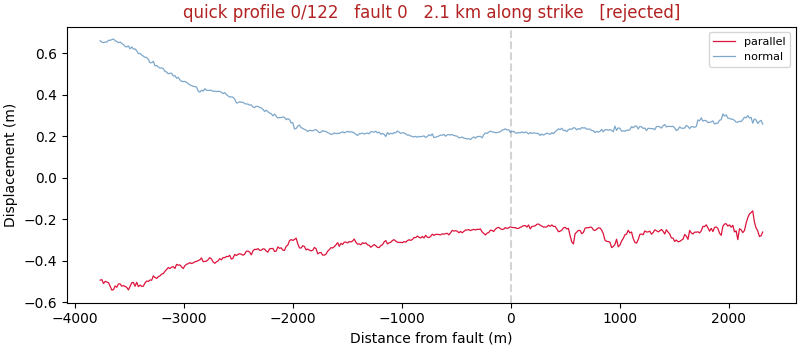

In [15]:
import ipywidgets as widgets

fig2, ax2 = plt.subplots(figsize=(8, 3.5), layout="constrained")

quick = pickle.load(open(MAIN / "results" / "working" / "tmp" / "quick_profiles.pickle", "rb"))
kept_keys = {(p.fault_id, round(p.x_along_fault, 3)) for p in picked}

def show_quick_profile(i=0):
    p = quick[i]
    kept = (p.fault_id, round(p.x_along_fault, 3)) in kept_keys
    ax2.clear()
    ax2.plot(p.xs, p.displacements[0], color="crimson", lw=0.9, label="parallel")
    ax2.plot(p.xs, p.displacements[1], color="steelblue", lw=0.9, alpha=0.7, label="normal")
    ax2.axvline(0, color="lightgray", ls="--", zorder=0)
    ax2.set_title(f"quick profile {i}/{len(quick) - 1}   fault {p.fault_id}   "
                 f"{p.x_along_fault / 1e3:.1f} km along strike   "
                 f"[{'KEPT' if kept else 'rejected'}]",
                 color="green" if kept else "firebrick")
    ax2.set_xlabel("Distance from fault (m)"); ax2.set_ylabel("Displacement (m)")
    ax2.legend(fontsize=8, loc="upper right")
    fig2.canvas.draw_idle()

widgets.interact(show_quick_profile,
                 i=widgets.BoundedIntText(value=0, min=0, max=len(quick) - 1, description="index:"));

## 7. Fault-aligned re-evaluation

Kept profiles are re-evaluated (`evaluate_profiles.py`, `codes.fault_aligned_profiles`) perpendicular to the *local* strike, relocated onto the peak shear-strain ridge, and median-stacked along strike. Two examples:

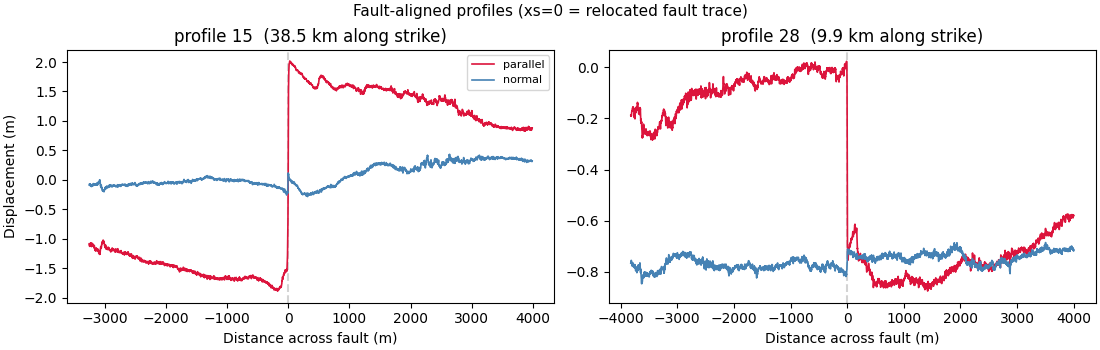

In [16]:
import pickle

evaluated = pickle.load(open(MAIN / "results" / "working" / "tmp" / "evaluated_profiles.pickle", "rb"))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), layout="constrained")
for ax, i in zip(axes, [15, 28]):
    p = evaluated[i]
    ax.plot(p.xs, p.displacements[0], color="crimson", lw=1.2, label="parallel")
    ax.plot(p.xs, p.displacements[1], color="steelblue", lw=1.2, label="normal")
    ax.axvline(0, color="lightgray", ls="--", zorder=0)
    ax.set_title(f"profile {i}  ({p.x_along_fault / 1e3:.1f} km along strike)")
    ax.set_xlabel("Distance across fault (m)")
axes[0].set_ylabel("Displacement (m)")
axes[0].legend(fontsize=8)
fig.suptitle("Fault-aligned profiles (xs=0 = relocated fault trace)", fontsize=11);

## 8. Deep-slip contribution removal

`remove_deep_slip_contribution.py` draws 1000 posterior slip models from the AlTar ensemble, keeps only patches below 2.5 km centroid depth, forward-predicts each profile's fault-parallel displacement (batched TDE Green's functions) and subtracts the ensemble mean from the data. The residual covariance combines the ensemble spread with the estimated data noise.

![deep removal 15](figures/deep_removal/profile_15.png)
![deep removal 09](figures/deep_removal/profile_09.png)

Model uncertainty stays well below the data noise almost everywhere:

![model vs noise](figures/deep_removal/summary_model_vs_noise.png)

## 9. 2D damage-zone inversion

<!-- Each deep-removed residual is inverted (`invert_twod_profiles.py`, Hamiltonian/NUTS) for a reduced-modulus damage zone plus 3 depth-patches of shallow strike-slip, using a dipping-fault extension of the Segall (2010) / Ragon & Simons (2021) antiplane image-series solution (`TwoDDzForwardModel`).

### 9.1 Forward-model validation

`test_twod_dz_forward.py`: image-series solution vs. an independent finite-difference solve of div(mu grad u)=0 with the slip jump, across the vertical, dipping-homogeneous, and dipping+damage-zone cases (~1% rms = discretisation error):

![forward validation](figures/twod/forward_validation.png) -->

### 9.2 Example profile fits

Each panel: shallow slip by depth patch, the data/model fit with posterior draws, and marginal posteriors (red = best/MAP sample). Left to right: a well-resolved damage zone; a clean fit but with modulus_ratio pinned at the 0.2 prior floor; a profile where the damage-zone parameters are essentially unconstrained.

![](figures/twod/profile_06.png)
![](figures/twod/profile_12.png)
![](figures/twod/profile_14.png)
![](figures/twod/profile_21.png)
![](figures/twod/profile_26.png)
![](figures/twod/profile_28.png)

### 9.3 Along-strike summary

MAP +/- 16-84th percentile for all 34 profiles, split by fault segment (main strand / foreshock strand — different along-strike ranges, so kept on separate axes):

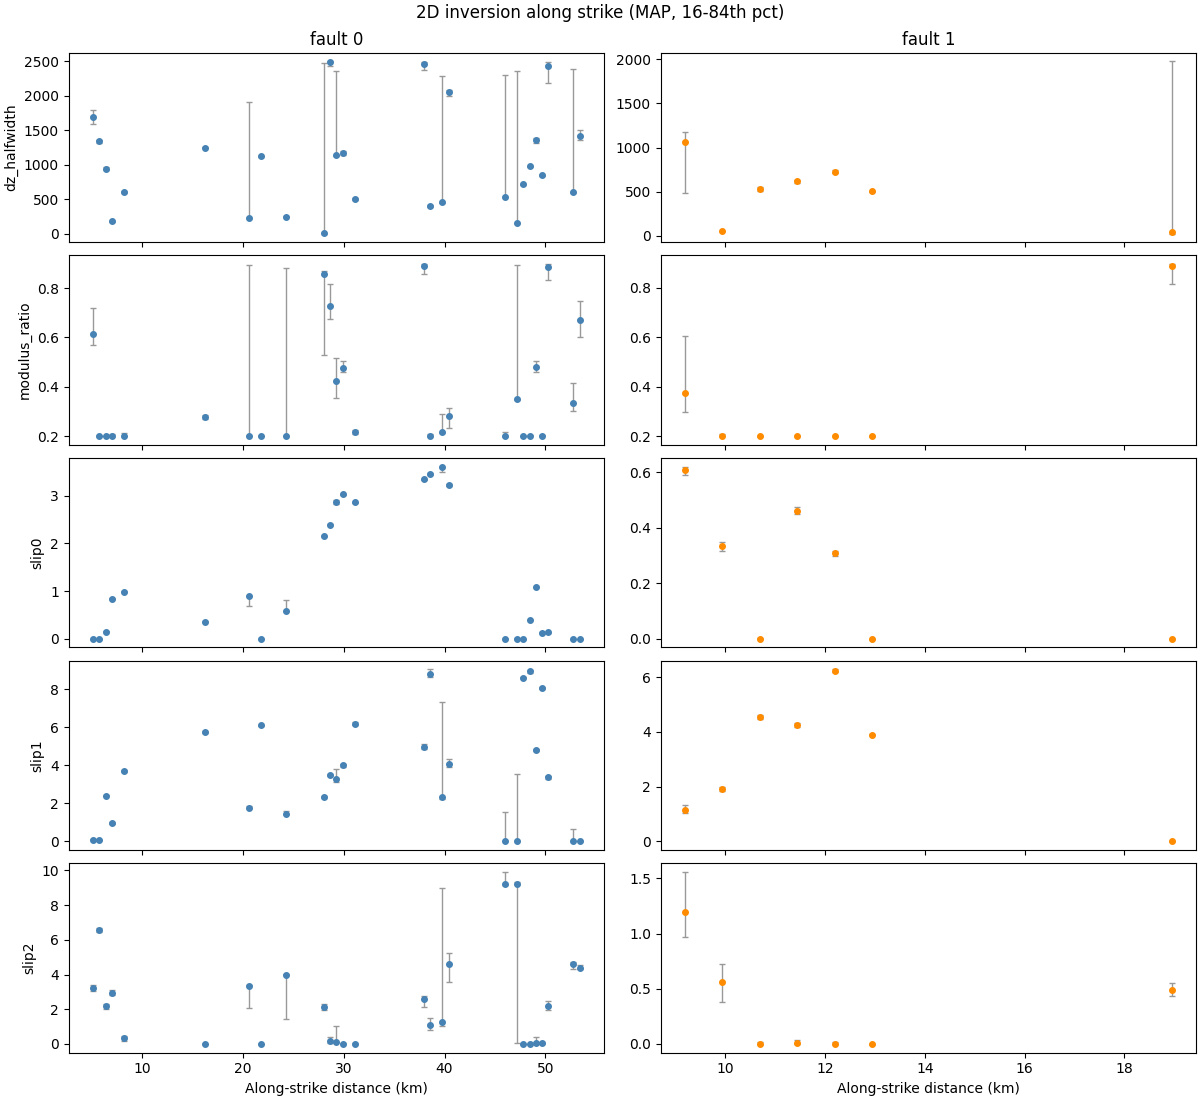

In [21]:
class _SafeUnpickler(pickle.Unpickler):
    """Result pickles carry an arviz InferenceData written with a different arviz
    version than is installed here; idata/sampler aren't needed for these summaries,
    so skip whatever no longer resolves."""
    def find_class(self, module, name):
        try:
            return super().find_class(module, name)
        except Exception:
            return type(name, (), {})

def _load(path):
    with open(path, "rb") as f:
        return _SafeUnpickler(f).load()

TWOD_DIR = MAIN / "results" / "profile_inversion" / "twod01"
results = [_load(p) for p in sorted(TWOD_DIR.glob("profile_*.pickle"))]

PARAMS = ["dz_halfwidth", "modulus_ratio", "slip0", "slip1", "slip2"]
x_strike = np.array([r["x_along_fault"] for r in results]) / 1e3
fault_id = np.array([r["fault_id"] for r in results])

fig, axes = plt.subplots(len(PARAMS), 2, figsize=(12, 11), sharex="col", layout="constrained")
for col, (fid, color) in enumerate([(0, "steelblue"), (1, "darkorange")]):
    m = fault_id == fid
    for row, param in enumerate(PARAMS):
        ax = axes[row, col]
        s = [r["summary"][param] for r in results]
        map_ = np.array([d["map"] for d in s])
        err = np.abs(np.vstack([map_ - [d["lo"] for d in s], [d["hi"] for d in s] - map_]))
        ax.errorbar(x_strike[m], map_[m], yerr=err[:, m], fmt="o", ms=4, color=color,
                   ecolor="0.6", elinewidth=1, capsize=2)
        if row == 0:
            ax.set_title(f"fault {fid}")
        if col == 0:
            ax.set_ylabel(param)
    axes[-1, col].set_xlabel("Along-strike distance (km)")
fig.suptitle("2D inversion along strike (MAP, 16-84th pct)", fontsize=12);

### 9.4 Convergence testing

<!-- `twod_convergence_test.py` ran two representative profiles (strong main-strand signal / weak foreshock signal) at 4 increasing sampler settings before committing to production settings (8 chains, 4000 draws, 2000 tune). Profile 28 is stable throughout; profile 15 shows a real secondary mode (some chains lock onto a spurious dz~2500 m solution) that only fully resolves with longer chains: -->

![convergence 28](figures/twod/convergence_profile_28.png)
![convergence 15](figures/twod/convergence_profile_15.png)

### 9.6 Re-run of 4 problem profiles under different conditions (2026-07-21)

**Profile 15 — mr floor lowered to 0.02.** Confirms the boundary problem: true mr = 0.14 [0.13,0.16], dz = 371 m (was pinned at mr=0.20/dz=399m), fit unchanged

![p15](figures/twod/profile_15_mrfloor002.png)

**Profile 24 — mr fixed at 0.5.** Doesn't resolve the problem, just relocates the wall: dz piles up against its own 2500 m *ceiling*

![p24](figures/twod/profile_24_fixmr05.png)

**Profile 8 — 128 dispersed-init chains.** The wide/high-mr mode is the majority (57% of chains vs 39% narrow), not a fluke. The original 8-chain run reported the *minority* basin purely from init-jitter luck — likely true for other bimodal profiles too (6, 14, 16, 18, 19, 23...).

![p8](figures/twod/profile_08_dispersed_chainmodes.png)

**Profile 7 — dip let free (±8° prior).**

![p7](figures/twod/profile_07_freedip.png)

### 9.7 Testing slip discretisations

3 profiles (15, 0, 28) x 3 slip-patch schemes (3/5/10 patches), all under matching settings (mr-lower=0.02, dispersed-init, 8 chains) so only the discretisation varies. **No conclusive benefit beyond ~5 patches**.

![disc3](figures/twod/profile_15_disc3.png)
![disc10](figures/twod/profile_15_disc10.png)